# Estimating Value-at-Risk of an Equally Weighted Multi-Asset Portfolio with GARCH-Family Models

# 1. Introduction

The primary objective of this project is to model, evaluate, and forecast the market risk of a multi-asset financial portfolio using advanced volatility econometric techniques. Specifically, we estimate and compare two distinct specifications from the GARCH family: a baseline symmetric **GARCH** model and an asymmetric **EGARCH** model. The ultimate goal is to generate dynamic 1-day-ahead **95% Value-at-Risk (VaR)** estimates and evaluate their predictive accuracy during an out-of-sample period using a rolling (walk-forward) approach.

# 2. Data Collection and Portfolio Construction

### Portfolio composition & asset selection
To capture diverse market behaviors and ensure a rich volatility structure, a multi-asset portfolio has been constructed comprising five distinct financial instruments. In compliance with the project guidelines, the portfolio is **equally weighted (20% per asset)** and rebalanced daily. The selected instruments are:
1. **Equity Index:** S&P 500 (`^GSPC`) — Serves as the benchmark for large-cap U.S. equity market equity risk.
2. **Company Stock:** NVIDIA (`NVDA`) — A high-growth, mega-cap technology stock selected to capture intense volatility clustering and corporate idiosyncratic shocks.
3. **Currency Pair:** EUR/USD (`EURUSD=X`) — The world's most liquid currency pair, exhibiting typical macroeconomic driven, low-variance fat-tailed characteristics.
4. **Commodity:** Gold (`GC=F`) — Included as a traditional "safe haven" asset that frequently exhibits safe-haven decoupling from traditional equities during market stress.
5. **Cryptocurrency:** Ethereum (`ETH-USD`) — A highly volatile digital asset included to inject strong non-linear dynamics, massive leptokurtosis, and persistent ARCH effects into the portfolio.

### Sample split

- **In-sample period:** starts on `2020-05-01` and ends on `2024-04-30`.
- **Out-of-sample period:** 365 calendar days starting on `2024-05-01`.
- **Out-of-sample end:** `2025-04-30`.

The notebook uses daily adjusted prices downloaded from Yahoo Finance through `yfinance`.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy import stats
from scipy.stats import norm, chi2
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, breaks_cusumolsresid

from arch import arch_model

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

tickers = ["^GSPC", "NVDA", "EURUSD=X", "GC=F", "ETH-USD"]

start = "2020-05-01"
insample_end = "2024-04-30"
oos_start = "2024-05-01"
oos_end = "2025-04-30"

download_start = "2020-04-15"
download_end = "2025-05-02"

alpha = 0.05  # 95% one-day VaR
weights = pd.Series(1/len(tickers), index=tickers) # All instruments equally weighted (20% in this case)

raw = yf.download(
    tickers,
    start=download_start,
    end=download_end,
    auto_adjust=True,
    progress=False,
    group_by="column"
)

Run the following code block to load the saved raw data, if necessary

In [5]:
# raw = pd.read_csv("raw_data.csv", header=[0,1], index_col=0, parse_dates=True)

### Forward-fill for data synchronization

Because our selected instruments trade on different calendars, the data are not perfectly aligned. To deal with this, missing prices are forward-filled, then log-returns are calculated. Specifically, the missing weekend prices for stocks and commodities are filled with the last available price (Friday's close). This is a practical way to deal with holidays and non-business days while keeping the portfolio weights equal at 20% each day.

In [6]:
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw.copy()

prices = prices[tickers]
prices = prices.sort_index()

daily_index = pd.date_range(prices.index.min(), prices.index.max(), freq="D")
prices_daily = prices.reindex(daily_index).ffill().dropna(how="any")

log_returns = np.log(prices_daily / prices_daily.shift(1)).dropna()
portfolio_returns = log_returns.dot(weights)
portfolio_returns.name = "portfolio_log_return"

portfolio_pct = 100 * portfolio_returns
portfolio_pct.name = "portfolio_return_pct"

insample = portfolio_pct.loc[start:insample_end].dropna()
oos = portfolio_pct.loc[oos_start:oos_end].dropna()

print("Prices shape:", prices_daily.shape)
print("Returns shape:", log_returns.shape)
print("In-sample observations:", len(insample), insample.index.min().date(), "to", insample.index.max().date())
print("Out-of-sample observations:", len(oos), oos.index.min().date(), "to", oos.index.max().date())
display(pd.concat([log_returns[tickers], portfolio_returns], axis=1).loc[start:oos_end].head())

Prices shape: (1843, 5)
Returns shape: (1842, 5)
In-sample observations: 1461 2020-05-01 to 2024-04-30
Out-of-sample observations: 365 2024-05-01 to 2025-04-30


,^GSPC,NVDA,EURUSD=X,GC=F,ETH-USD,portfolio_log_return
2020-05-01,-0.028460,-0.033043,0.006252,0.006097,0.031376,-0.003556
2020-05-02,0.000000,0.000000,0.000000,0.000000,0.005151,0.001030
2020-05-03,0.000000,0.000000,0.000000,0.000000,-0.020609,-0.004122
2020-05-04,0.004241,0.029650,0.001292,0.007291,-0.013167,0.005862
2020-05-05,0.009000,0.008376,-0.005062,-0.001466,-0.006746,0.000820


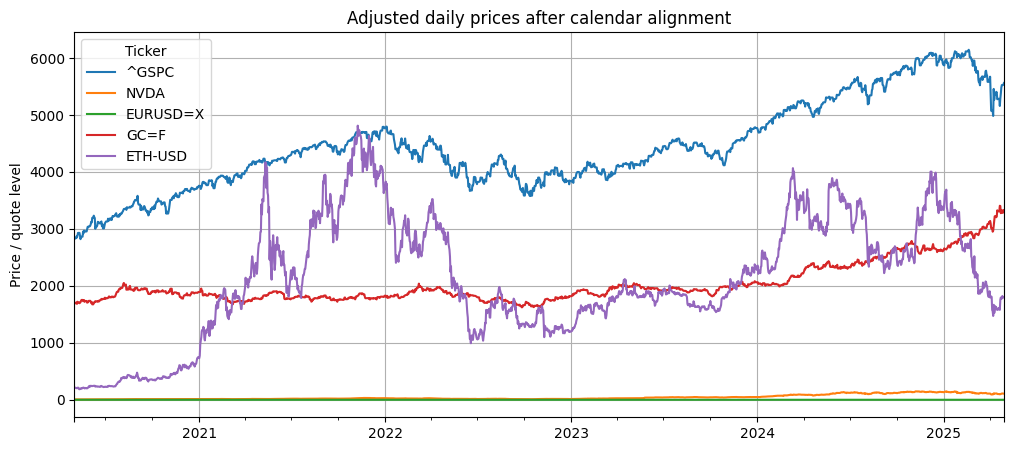

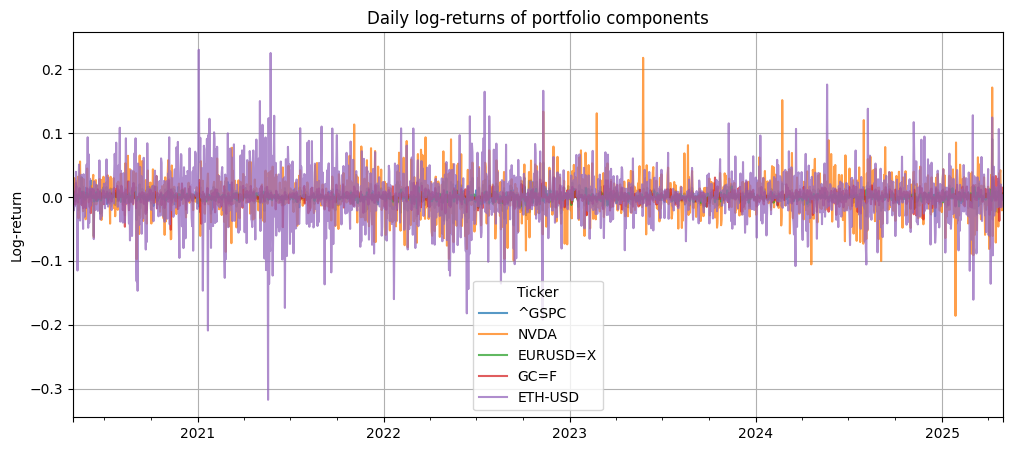

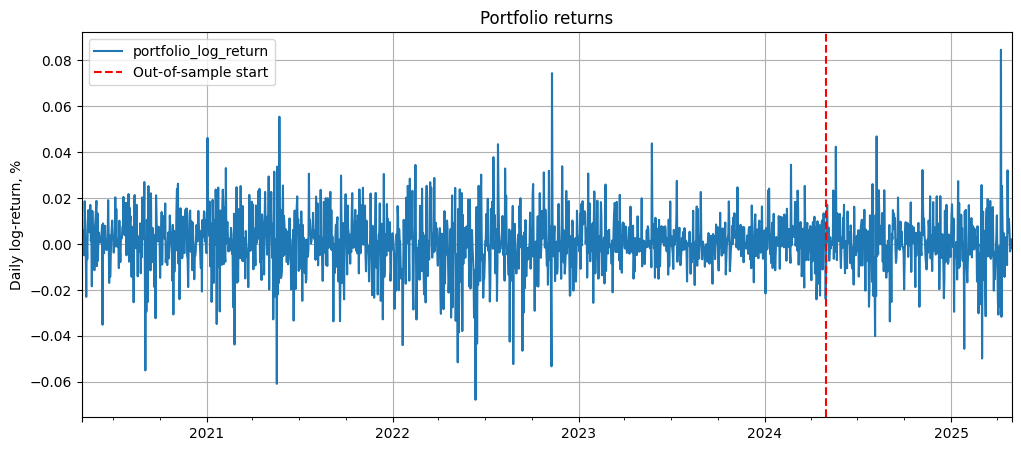

In [7]:
fig, ax = plt.subplots()
prices_daily.loc[start:oos_end, tickers].plot(ax=ax)
ax.set_title("Adjusted daily prices after calendar alignment")
ax.set_ylabel("Price / quote level")
plt.show()

fig, ax = plt.subplots()
log_returns.loc[start:oos_end, tickers].plot(ax=ax, alpha=0.75)
ax.set_title("Daily log-returns of portfolio components")
ax.set_ylabel("Log-return")
plt.show()

fig, ax = plt.subplots()
portfolio_returns.loc[start:oos_end].plot(ax=ax)
ax.axvline(pd.Timestamp(oos_start), linestyle="--", color="red", label="Out-of-sample start")
ax.set_title("Portfolio returns")
ax.set_ylabel("Daily log-return, %")
ax.legend()
plt.show()

# 3. Exploratory Data Analysis

Financial returns usually display several stylized facts:

1. **Volatility clustering:** large absolute returns tend to be followed by large absolute returns.
2. **Leptokurtosis:** return distributions often have heavier tails than the normal distribution.
3. **ARCH effects:** squared returns are autocorrelated, which motivates conditional volatility models.
4. **Weak linear autocorrelation of raw returns:** raw daily returns are often close to serially uncorrelated, but their squares are not.

The following cells check these facts using plots, descriptive statistics, ACF/PACF, Ljung-Box tests, and ARCH LM tests.

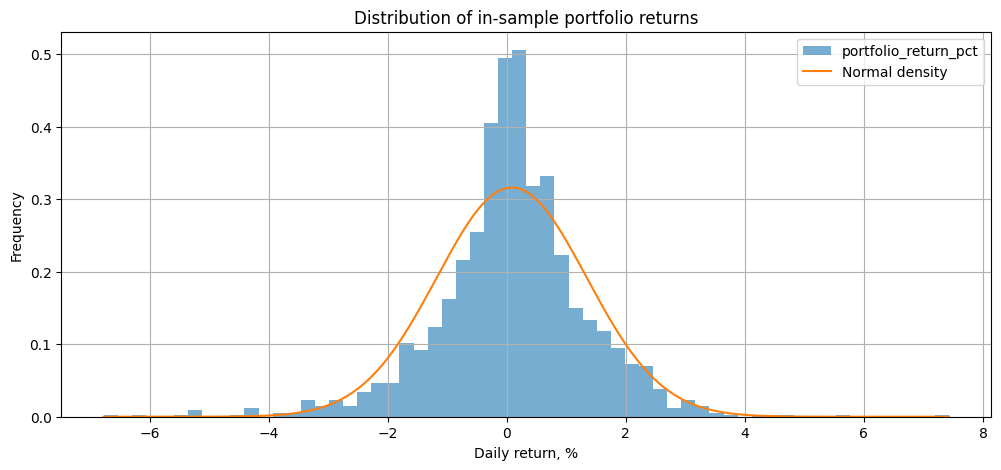

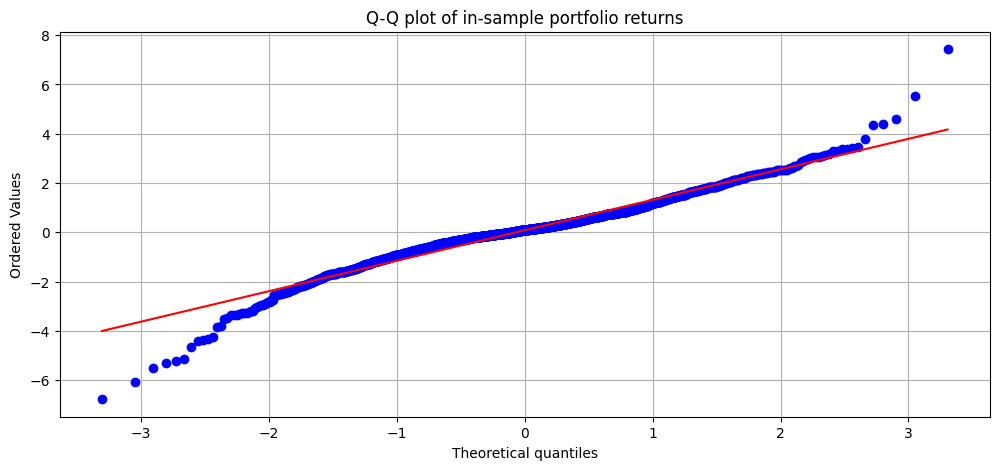

,mean,std,skewness,excess_kurtosis,min,max
portfolio in-sample returns (%),0.082,1.2615,-0.3351,3.2722,-6.7766,7.4298


In [8]:
fig, ax = plt.subplots()
insample.plot(kind="hist", bins=60, density=True, alpha=0.6, ax=ax)
x = np.linspace(insample.min(), insample.max(), 500)
ax.plot(x, norm.pdf(x, insample.mean(), insample.std()), label="Normal density")
ax.set_title("Distribution of in-sample portfolio returns")
ax.set_xlabel("Daily return, %")
ax.legend()
plt.show()

fig, ax = plt.subplots()
stats.probplot(insample, dist="norm", plot=ax)
ax.set_title("Q-Q plot of in-sample portfolio returns")
plt.show()

summary = pd.DataFrame({
    "mean": [insample.mean()],
    "std": [insample.std()],
    "skewness": [stats.skew(insample)],
    "excess_kurtosis": [stats.kurtosis(insample, fisher=True)],
    "min": [insample.min()],
    "max": [insample.max()]
}, index=["portfolio in-sample returns (%)"])

display(summary.round(4))

Both the histogram and the Q-Q plot indicate that the portfolio returns exhibit a non-normal distribution characterized by slight negative skewness and significant leptokurtosis. The presence of heavy tails suggests an elevated probability of extreme market movements, which supports the use of GARCH and EGARCH models in subsequent volatility and Value-at-Risk analysis.

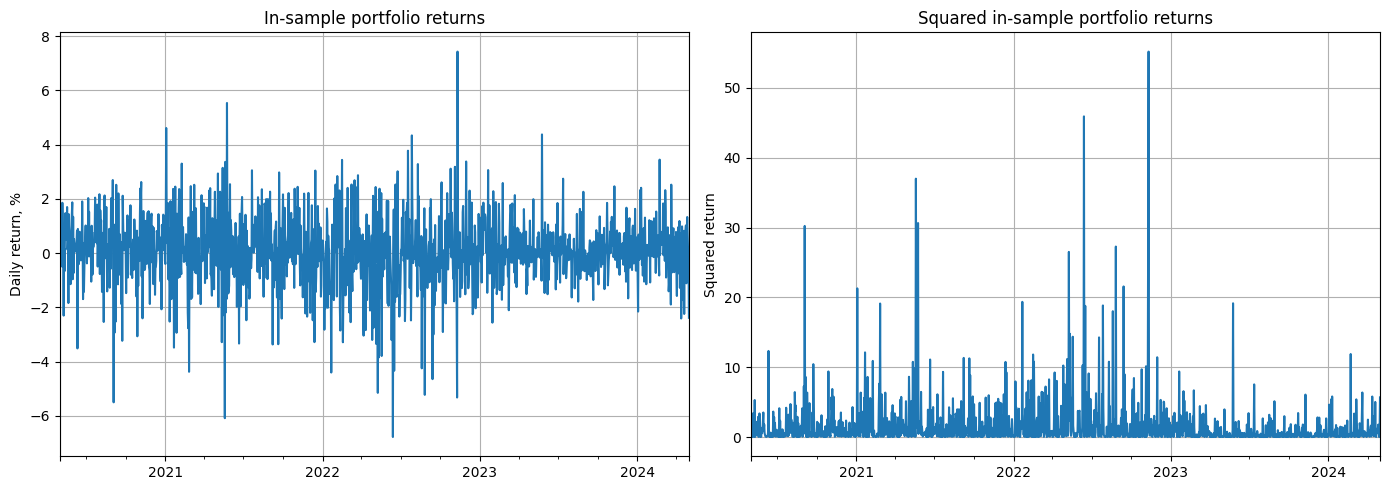

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

insample.plot(ax=axs[0])
axs[0].set_title("In-sample portfolio returns")
axs[0].set_ylabel("Daily return, %")

(insample**2).plot(ax=axs[1])
axs[1].set_title("Squared in-sample portfolio returns")
axs[1].set_ylabel("Squared return")

plt.tight_layout()
plt.show()

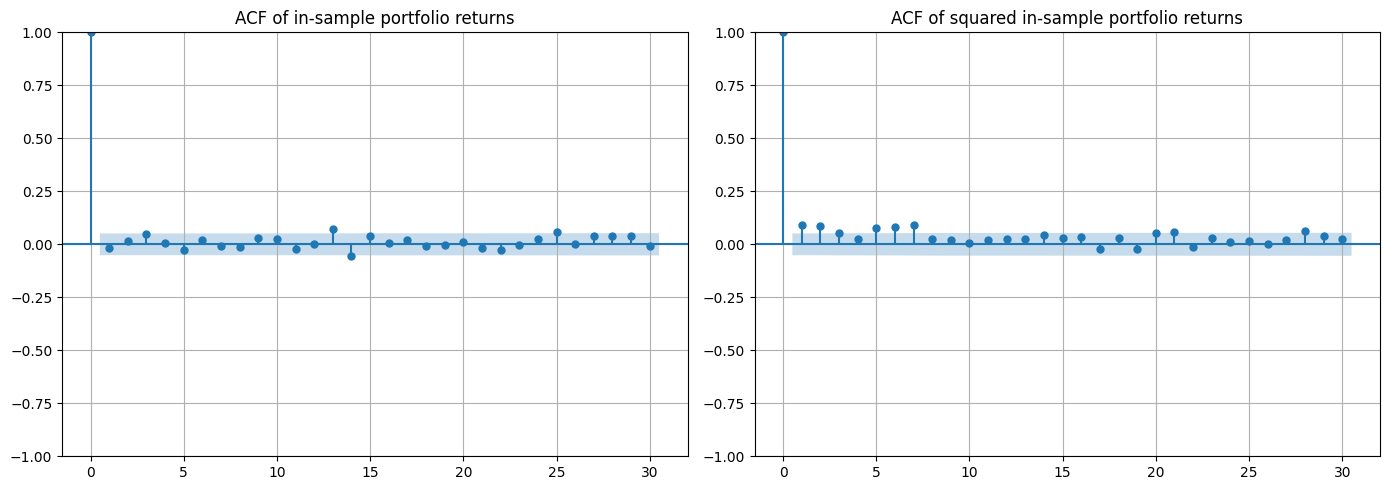

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(insample, lags=30, ax=axs[0])
axs[0].set_title("ACF of in-sample portfolio returns")

plot_acf(insample**2, lags=30, ax=axs[1])
axs[1].set_title("ACF of squared in-sample portfolio returns")

plt.tight_layout()
plt.show()

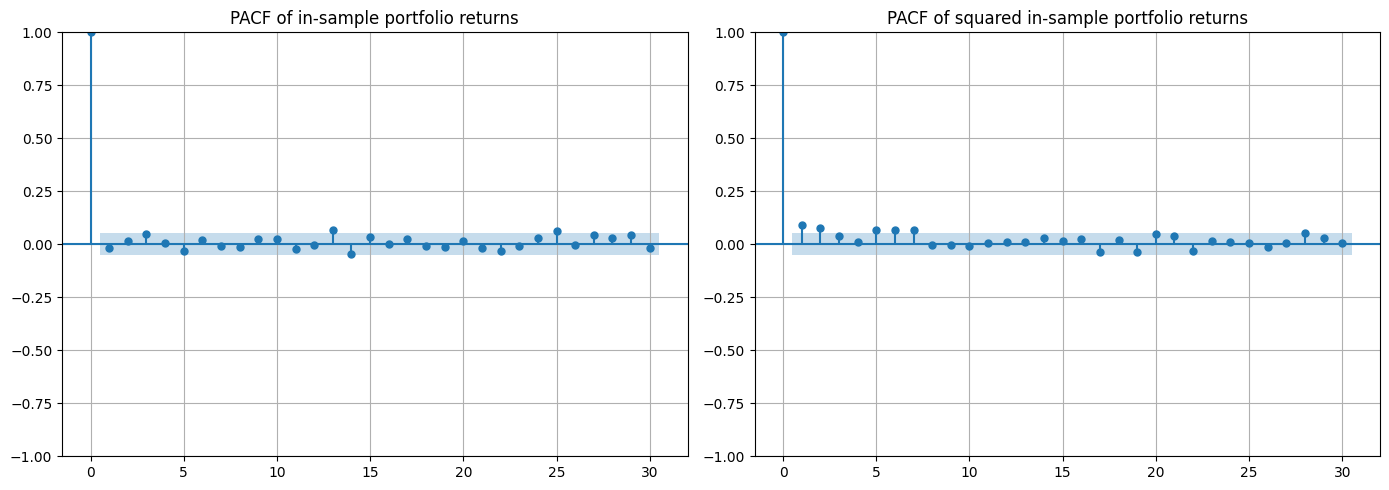

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

plot_pacf(insample, lags=30, method="ywm", ax=axs[0])
axs[0].set_title("PACF of in-sample portfolio returns")

plot_pacf(insample**2, lags=30, method="ywm", ax=axs[1])
axs[1].set_title("PACF of squared in-sample portfolio returns")

plt.tight_layout()
plt.show()

In [12]:
lb_ret = acorr_ljungbox(insample, lags=[10, 20], return_df=True)
lb_sq = acorr_ljungbox(insample**2, lags=[10, 20], return_df=True)
arch_lm = het_arch(insample, nlags=10)

print("Ljung-Box test for raw returns:")
display(lb_ret)

print("Ljung-Box test for squared returns:")
display(lb_sq)

print("ARCH LM test with 10 lags:")
print(f"LM statistic = {arch_lm[0]:.4f}, p-value = {arch_lm[1]:.4f}")

Ljung-Box test for raw returns:


,lb_stat,lb_pvalue
10,8.521834,0.578002
20,24.085986,0.238656


Ljung-Box test for squared returns:


,lb_stat,lb_pvalue
10,61.884118,1.591956e-09
20,77.098025,1.213644e-08


ARCH LM test with 10 lags:
LM statistic = 44.0824, p-value = 0.0000


### Interpretation of stylized facts

The portfolio returns plot shows periods of relatively calm fluctuations alternating with periods of heightened volatility. In particular, large positive and negative returns tend to occur in clusters rather than being evenly distributed over time. This **volatility clustering** phenomenon suggests that volatility is time-varying rather than constant.

The squared returns series highlights this pattern even more clearly. **Several periods contain consecutive large values of squared returns, indicating persistent episodes of high volatility. Such persistence suggests that shocks to volatility tend to have lasting effects**.

The ACF and PACF plots for the raw returns show that most autocorrelations lie within the confidence bands, indicating little or no linear dependence in the mean process. This result is confirmed by the Ljung–Box test for raw returns, which fails to reject the null hypothesis of no autocorrelation (p-values of 0.578 and 0.239 for lags 10 and 20, respectively). Therefore, the portfolio returns behave similarly to a white-noise process in the mean.

In contrast, **the ACF and PACF of squared returns reveal several significant positive autocorrelations at low lags, indicating persistence in the variance process**. The Ljung–Box test applied to squared returns strongly rejects the null hypothesis of no autocorrelation (p-values below 0.001 at both lag specifications). Furthermore, the ARCH-LM test produces a highly significant result (LM statistic = 44.08, p-value < 0.001), providing strong evidence of ARCH effects.

Overall, the results indicate that while the portfolio returns themselves exhibit little serial dependence, their volatility is clearly autocorrelated and clustered over time. These findings further justify the application of GARCH-family models, which are specifically designed to capture conditional heteroskedasticity and time-varying volatility in financial return series.

# 4. Data Modelling

### GARCH modelling

We start by fitting our data to simple **GARCH** models. A set of simple GARCH(p, q) models is estimated using Student's t innovations. The reason for choosing the Student's t distribution instead of the Normal distribution is that the return distribution is expected to be heavy-tailed.

The model selection process considers **AIC, BIC, Ljung-Box tests** for standardized residuals, **Ljung-Box tests** for squared standardized residuals, **ARCH LM tests**, conditional standard deviation behavior, and **ACF plots** of standardized and squared standardized residuals. 

The model's performance can be evaluated by AIC or BIC. The GARCH and EGARCH models that minimize these criteria will be selected as our final models. Here, **BIC is preferred** as it penalizes model complexity more harshly, preventing overfitting in out-of-sample forecasting.

In [13]:
def fit_garch_model(y, p=1, q=1, vol="GARCH", dist="t"):
    model = arch_model(
        y,
        mean="Constant",
        vol=vol,
        p=p,
        o=0,
        q=q,
        dist=dist,
        rescale=False
    )
    return model.fit(disp="off")

def generate_diagnostics_table(res, lags=20):
    z = pd.Series(res.std_resid, index=res.resid.index).dropna()
    lb_z = acorr_ljungbox(z, lags=[lags], return_df=True)
    lb_z2 = acorr_ljungbox(z**2, lags=[lags], return_df=True)
    arch = het_arch(z, nlags=10)
    return {
        "lb_resid_pvalue": lb_z["lb_pvalue"].iloc[0],
        "lb_sq_resid_pvalue": lb_z2["lb_pvalue"].iloc[0],
        "arch_lm_pvalue": arch[1],
    }

results = []

for p in range(1, 4):
    for q in range(1, 4):
        try:
            res = fit_garch_model(insample, p=p, q=q, vol="GARCH", dist="t")
            diag = generate_diagnostics_table(res, lags=20)
            results.append({
                "model": f"GARCH({p},{q})-t",
                "p": p,
                "q": q,
                "aic": res.aic,
                "bic": res.bic,
                **diag
            })
        except Exception as e:
            results.append({
                "model": f"GARCH({p},{q})-t",
                "p": p,
                "q": q,
                "aic": np.nan,
                "bic": np.nan,
                "lb_resid_pvalue": np.nan,
                "lb_sq_resid_pvalue": np.nan,
                "arch_lm_pvalue": np.nan,
                "error": str(e)
            })

garch_grid = pd.DataFrame(results).sort_values(["bic", "aic"])
display(garch_grid.round(4))

,model,p,q,aic,bic,lb_resid_pvalue,lb_sq_resid_pvalue,arch_lm_pvalue
0,"GARCH(1,1)-t",1,1,4577.3757,4603.8101,0.7152,0.3557,0.1829
3,"GARCH(2,1)-t",2,1,4579.3199,4611.0411,0.7152,0.3430,0.1799
1,"GARCH(1,2)-t",1,2,4579.3757,4611.0970,0.7152,0.3557,0.1829
4,"GARCH(2,2)-t",2,2,4580.0896,4617.0977,0.6953,0.3705,0.2395
2,"GARCH(1,3)-t",1,3,4581.1314,4618.1396,0.7142,0.3895,0.2051
6,"GARCH(3,1)-t",3,1,4581.3199,4618.3280,0.7152,0.3430,0.1799
5,"GARCH(2,3)-t",2,3,4579.1808,4621.4758,0.7185,0.3699,0.2226
7,"GARCH(3,2)-t",3,2,4582.0896,4624.3846,0.6953,0.3705,0.2395
8,"GARCH(3,3)-t",3,3,4580.6399,4628.2218,0.7274,0.3270,0.1881


All candidate models successfully passed the residual diagnostic hurdles at the 5% significance level ($p$-values $> 0.05$). This indicates a failure to reject the null hypotheses, confirming that:
* **No remaining autocorrelation** exists in the standardized residuals.
* **No remaining volatility clustering or ARCH effects** persist in the squared standardized residuals.

Because all models are statistically adequate and successfully filter out the time-varying risk, the final selection is determined by the **BIC**. We select the **GARCH(1,1)-t** model, as it achieves the lowest **BIC (4603.8101)**, representing the optimal balance between model fit and parameter simplicity.

In [14]:
selected_row = garch_grid.sort_values("bic").iloc[0]

p_best, q_best = int(selected_row["p"]), int(selected_row["q"])
print("Selected simple GARCH specification:", selected_row["model"])
print("p_best =", p_best, "q_best =", q_best)

garch_res = fit_garch_model(insample, p=p_best, q=q_best, vol="GARCH", dist="t")
print(garch_res.summary())

Selected simple GARCH specification: GARCH(1,1)-t
p_best = 1 q_best = 1
                        Constant Mean - GARCH Model Results                         
Dep. Variable:         portfolio_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2283.69
Distribution:      Standardized Student's t   AIC:                           4577.38
Method:                  Maximum Likelihood   BIC:                           4603.81
                                              No. Observations:                 1461
Date:                      Wed, Jun 24 2026   Df Residuals:                     1460
Time:                              21:05:23   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------

### Interpretation of GARCH parameters

The optimization process yielded a highly stable and statistically significant fit for the selected **GARCH(1,1)-t** model over the 1,461 daily observations:

* **Expected Mean Return ($\mu = 0.1103$)**: The portfolio has a statistically significant positive daily drift of approximately **0.11%** ($p$-value $< 0.001$).
* **Shock Sensitivity ($\alpha_1 = 0.0283$)**: The immediate impact of market shocks on current-day volatility is relatively small. Only about **2.83%** of a fresh return shock feeds directly into the next period's variance. 
* **Volatility Persistence ($\beta_1 = 0.9712$)**: Volatility exhibits extreme persistence ($p$-value $< 0.001$). Combined with $\alpha_1$, the persistence parameter sums up close to unity ($\alpha_1 + \beta_1 = 0.9995$), confirming that **market shocks decay exceptionally slowly, causing extended periods of volatility clustering**.
* **Heavy Tails ($\nu = 4.0649$)**: The degrees of freedom parameter for the Student's $t$-distribution is highly significant ($p$-value $< 0.001$). This value (~4.06) confirms that the portfolio returns are heavily fat-tailed, exhibiting frequent extreme outliers that a standard Normal distribution would fail to capture.

### EGARCH modelling

The second model is **EGARCH**, estimated with the same selected lag structure as the simple GARCH benchmark. EGARCH is useful because it allows **asymmetric volatility responses**: negative and positive shocks may affect future volatility differently. Likewise, our EGARCH models use Student's t innovations for heavy-tailed returns.

In [15]:
egarch_model = arch_model(
    insample,
    mean="Constant",
    vol="EGARCH",
    p=p_best,
    o=1,
    q=q_best,
    dist="t",
    rescale=False
)
egarch_res = egarch_model.fit(disp="off")
print(egarch_res.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:         portfolio_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2281.55
Distribution:      Standardized Student's t   AIC:                           4575.09
Method:                  Maximum Likelihood   BIC:                           4606.82
                                              No. Observations:                 1461
Date:                      Wed, Jun 24 2026   Df Residuals:                     1460
Time:                              21:05:23   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

### Interpretation of EGARCH parameters

The EGARCH model accounts for time-varying risk by modeling the log-variance process, yielding the following insights:

* **Expected Mean Return ($\mu = 0.1021$)**: Consistent with the previous model, the portfolio maintains a statistically significant positive daily drift of approximately **0.10%** ($p$-value $< 0.001$).
* **Shock Magnitude Sensitivity ($\alpha_1 = 0.0638$)**: This parameter captures the magnitude effect of market shocks. A value of **0.0638** ($p$-value $< 0.001$) indicates that the absolute size of market surprises has a significant, positive impact on upcoming log-volatility.
* **Absence of Leverage Effect ($\gamma_1 = -0.0001$)**: The asymmetry parameter is exceptionally close to zero, and its $p$-value is highly insignificant (**0.992**). This provides definitive statistical proof that **bad news does not generate more volatility than good news** for this specific portfolio. The news impact remains almost perfectly symmetric.
* **Log-Volatility Persistence ($\beta_1 = 0.9957$)**: The persistence parameter for log-variance is exceptionally high and statistically significant ($p$-value $< 0.001$). This confirms that **volatility innovations are highly integrated and decay at a very slow rate over time**.
* **Heavy Tails ($\nu = 4.1477$)**: The degrees of freedom parameter remains highly significant ($p$-value $< 0.001$). A value of ~4.15 reinforces that the return distribution possesses fat tails with frequent extreme outliers.

# 5. Diagnostics of Selected GARCH and EGARCH Models

This section performs and interprets the required diagnostics:

- Ljung-Box test for standardized residuals,
- Ljung-Box test for squared standardized residuals,
- ARCH LM test,
- conditional standard deviation plots,
- ACF of standardized residuals,
- ACF of squared standardized residuals,
- a parameter stability diagnostic similar to a Nyblom stability test,
- Engle-Ng sign bias test,
- adjusted Pearson goodness-of-fit test using probability integral transforms.


GARCH(1, 1): diagnostics
--------------------------------------------------------------------------------


,lb_resid_pvalue,lb_sq_resid_pvalue,arch_lm_pvalue
"GARCH(1, 1)",0.7152,0.3557,0.1829


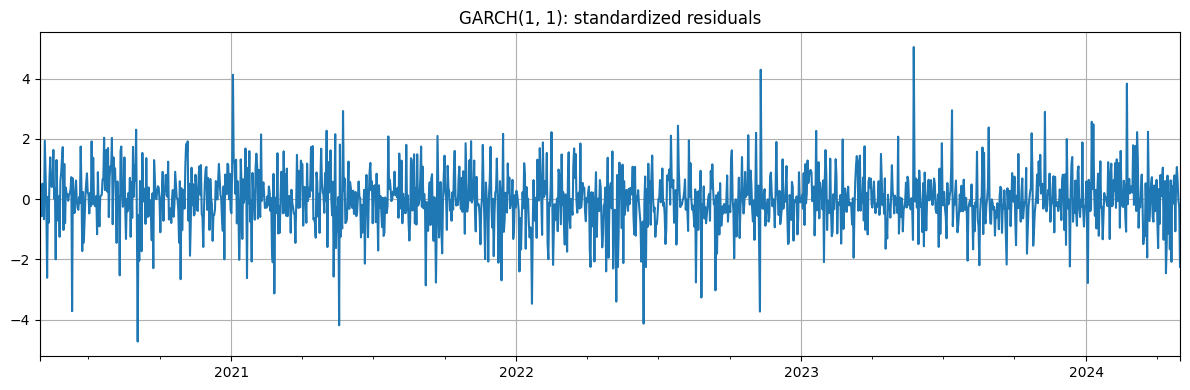

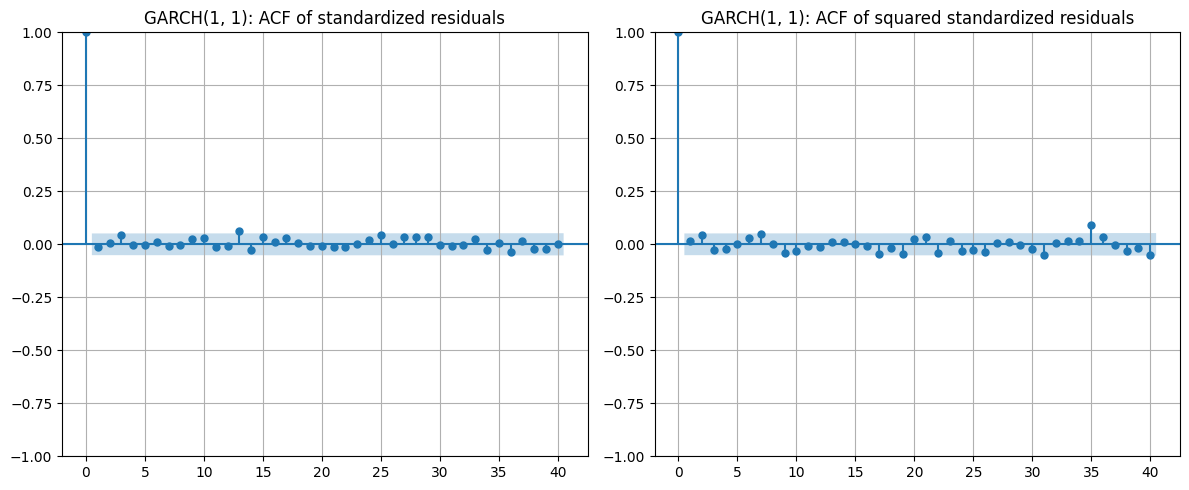


EGARCH(1, 1): diagnostics
--------------------------------------------------------------------------------


,lb_resid_pvalue,lb_sq_resid_pvalue,arch_lm_pvalue
"EGARCH(1, 1)",0.735,0.1762,0.1119


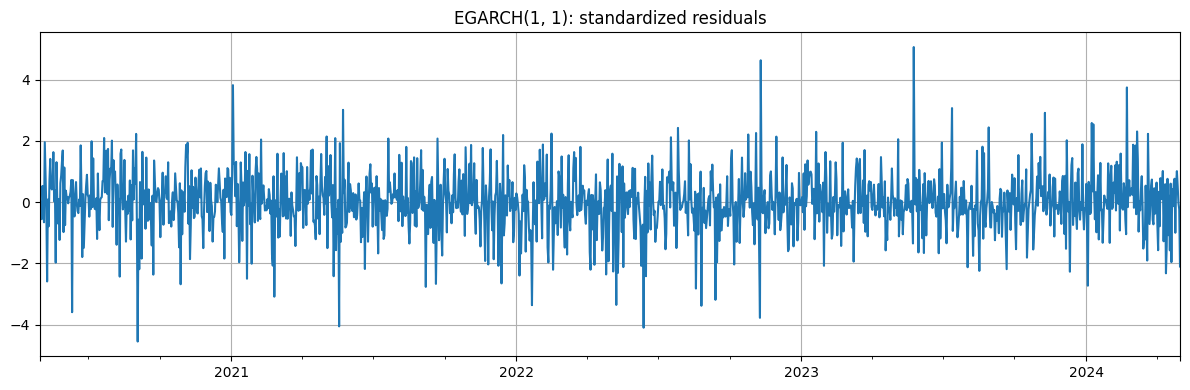

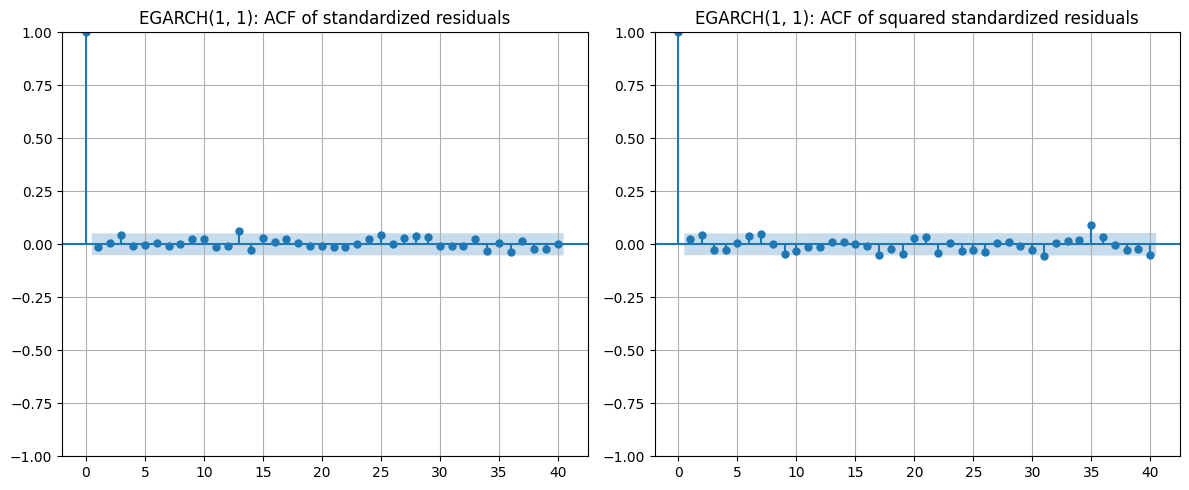

In [16]:
def generate_diagnostics_plots(res, name, lags=20):

    z = pd.Series(res.std_resid, index=res.resid.index).dropna()
    cond_vol = pd.Series(res.conditional_volatility, index=res.resid.index).dropna()

    print(f"\n{name}: diagnostics")
    print("-" * 80)
    display(pd.DataFrame([generate_diagnostics_table(res, lags=lags)], index=[name]).round(4))

    fig, ax = plt.subplots(figsize=(12, 4))
    z.plot(ax=ax)
    ax.set_title(f"{name}: standardized residuals")
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    plot_acf(z, lags=40, ax=axs[0])
    axs[0].set_title(f"{name}: ACF of standardized residuals")
    plot_acf(z**2, lags=40, ax=axs[1])
    axs[1].set_title(f"{name}: ACF of squared standardized residuals")

    plt.tight_layout()
    plt.show()

    return z, cond_vol

z_garch, sigma_garch = generate_diagnostics_plots(garch_res, f"GARCH({p_best}, {q_best})")
z_egarch, sigma_egarch = generate_diagnostics_plots(egarch_res, f"EGARCH({p_best}, {q_best})")

As mentioned earlier, the models passed the Ljung-Box test for standardized residuals, Ljung-Box test for squared standardized residuals,
and the ARCH LM test. No remaining autocorrelation exists in the standardized residuals, and no remaining volatility clustering or ARCH effects persist in the squared standardized residuals. The ACF plots of standardized residuals and squared standardized residuals further confirm this. For both models:

1. **No Remaining Autocorrelation** (Left Plot): All lags after lag 0 fall within the 95% confidence interval (blue shaded region). This proves the model has successfully captured the linear dependencies in the data, leaving no predictable patterns in the residuals.

2. **No Remaining Volatility Clustering / ARCH Effects** (Right Plot): The squared residuals show no significant patterns crossing the confidence threshold. The lack of structured spikes confirms that the model has completely filtered out the time-varying volatility risk.

In [17]:
def extra_garch_diagnostics(res, name, bins=20):
    z = pd.Series(res.std_resid).dropna()

    # 1. Nyblom-like stability test: CUSUM test
    ols = sm.OLS(z, np.ones(len(z))).fit()
    cusum_stat, cusum_p, _ = breaks_cusumolsresid(ols.resid, ddof=1)

    # 2. Engle-Ng sign bias test
    lag_z = z.shift(1).dropna()
    y = z.loc[lag_z.index] ** 2
    neg = (lag_z < 0).astype(int)

    X = sm.add_constant(pd.DataFrame({
        "sign": neg,
        "neg_size": neg * lag_z,
        "pos_size": (1 - neg) * lag_z
    }))

    sign_model = sm.OLS(y, X).fit()
    joint_stat = len(y) * sign_model.rsquared
    joint_p = 1 - stats.chi2.cdf(joint_stat, df=3)

    # 3. Adjusted Pearson goodness-of-fit test
    u = stats.norm.cdf(z)
    observed, _ = np.histogram(u, bins=np.linspace(0, 1, bins + 1))
    expected = np.repeat(len(u) / bins, bins)
    pearson_stat = ((observed - expected) ** 2 / expected).sum()
    pearson_p = 1 - stats.chi2.cdf(pearson_stat, df=bins - 1)

    print(f"\n{name}")
    print("-" * len(name))

    print(f"CUSUM stability test: stat={cusum_stat:.4f}, p-value={cusum_p:.4f}")

    print("\nSign Bias Test:")
    display(pd.DataFrame({
        "coef": sign_model.params,
        "t-stat": sign_model.tvalues,
        "p-value": sign_model.pvalues
    }))

    print(f"Joint sign bias test: stat={joint_stat:.4f}, p-value={joint_p:.4f}")

    print(f"\nAdjusted Pearson GOF: stat={pearson_stat:.4f}, p-value={pearson_p:.4f}")

extra_garch_diagnostics(garch_res, "GARCH(1,1)")
extra_garch_diagnostics(egarch_res, "EGARCH(1,1)")


GARCH(1,1)
----------
CUSUM stability test: stat=1.2329, p-value=0.0956

Sign Bias Test:


,coef,t-stat,p-value
const,0.954511,8.791317,4.084675e-18
sign,-0.127417,-0.856589,3.918132e-01
neg_size,-0.224038,-2.147479,3.191983e-02
pos_size,-0.100222,-0.880996,3.784653e-01


Joint sign bias test: stat=6.2890, p-value=0.0984

Adjusted Pearson GOF: stat=139.2875, p-value=0.0000

EGARCH(1,1)
-----------
CUSUM stability test: stat=1.2069, p-value=0.1086

Sign Bias Test:


,coef,t-stat,p-value
const,0.940005,8.822851,3.127539e-18
sign,-0.105440,-0.712957,4.759864e-01
neg_size,-0.236075,-2.255750,2.423421e-02
pos_size,-0.092470,-0.827577,4.080457e-01


Joint sign bias test: stat=7.2501, p-value=0.0643

Adjusted Pearson GOF: stat=124.8590, p-value=0.0000


### Interpretation of additional diagnostic tests

After running the diagnostics:

- **CUSUM Stability Test:** both GARCH(1,1) (p-value = 0.0956) and EGARCH(1,1) (p-value = 0.1086) fail to reject parameter instability at the 5% significance level, suggesting that the estimated model parameters remain reasonably stable throughout the sample period.

- **Sign Bias Test:** the joint Sign Bias test is insignificant for both GARCH(1,1) (p-value = 0.0984) and EGARCH(1,1) (p-value = 0.0643), indicating no strong evidence of remaining asymmetric effects in the standardized residuals. However, the negative size bias term is significant in both models (p-values below 0.05), suggesting that large negative shocks may still have some additional impact on volatility.

- **Adjusted Pearson Goodness-of-Fit Test:** both models strongly reject the assumed innovation distribution (p-value < 0.001), indicating that the standardized residuals still exhibit distributional features, such as heavy tails, that are not fully captured by the models.

# 6. Annualized Conditional Standard Deviation in the In-Sample Period

To calculate the annualized volatility, we multiply the conditional standard deviation outputs from the GARCH models by the square root of 252, which is the standard approximation for annualizing daily financial volatility. Because the returns were scaled earlier by multiplying by 100, the conditional_volatility output is also scaled up by 100. Therefore, the values shown here are percentage values. 

,count,mean,std,min,25%,50%,75%,max
GARCH,1461.0,20.4035,4.8232,12.1078,16.1789,20.4141,23.8097,33.0974
EGARCH,1461.0,20.2614,4.5822,11.7736,15.9705,20.8222,23.5798,31.2276


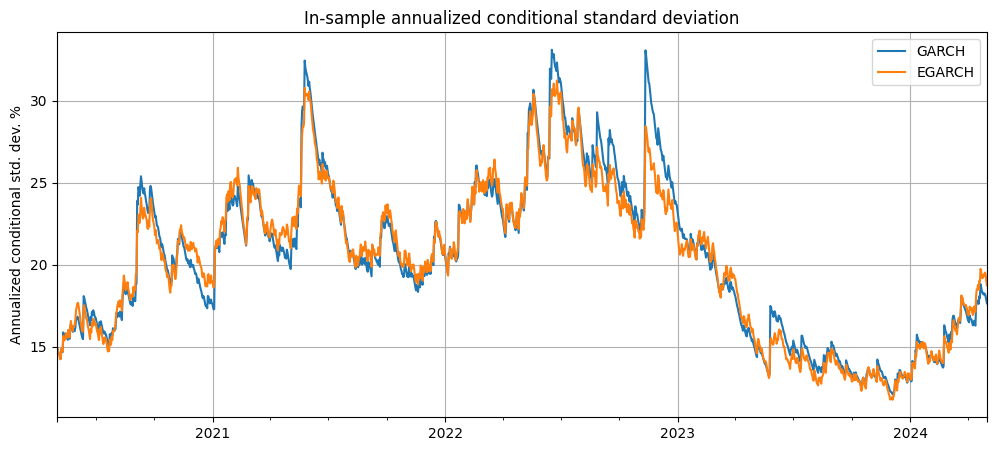

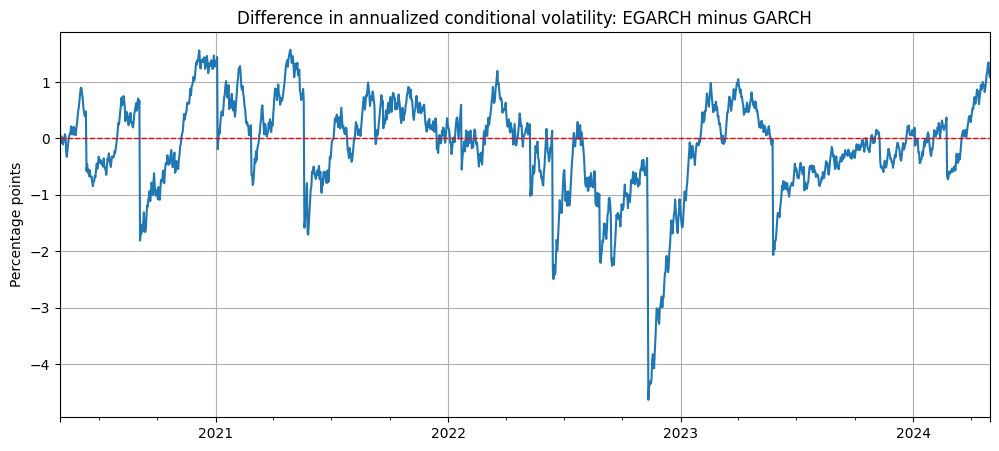

In [18]:
annualized_vol = pd.DataFrame({
    "GARCH": sigma_garch * np.sqrt(252),
    "EGARCH": sigma_egarch * np.sqrt(252)
}).dropna()

display(annualized_vol.describe().T.round(4))

fig, ax = plt.subplots()
annualized_vol.plot(ax=ax)
ax.set_title("In-sample annualized conditional standard deviation")
ax.set_ylabel("Annualized conditional std. dev. %")
plt.show()

fig, ax = plt.subplots()
(annualized_vol["EGARCH"] - annualized_vol["GARCH"]).plot(ax=ax)
ax.axhline(0, linewidth=1, linestyle="--", color="red")
ax.set_title("Difference in annualized conditional volatility: EGARCH minus GARCH")
ax.set_ylabel("Percentage points")
plt.show()

# 7. News Impact Curves

News Impact Curves show how the next-period conditional variance reacts to a shock. They help interpret the volatility response and are especially useful for comparing symmetric GARCH with asymmetric EGARCH.

For GARCH, the curve is symmetric: positive and negative shocks of the same size have the same effect.

For EGARCH, the curve may be asymmetric: the sign of the shock can matter.

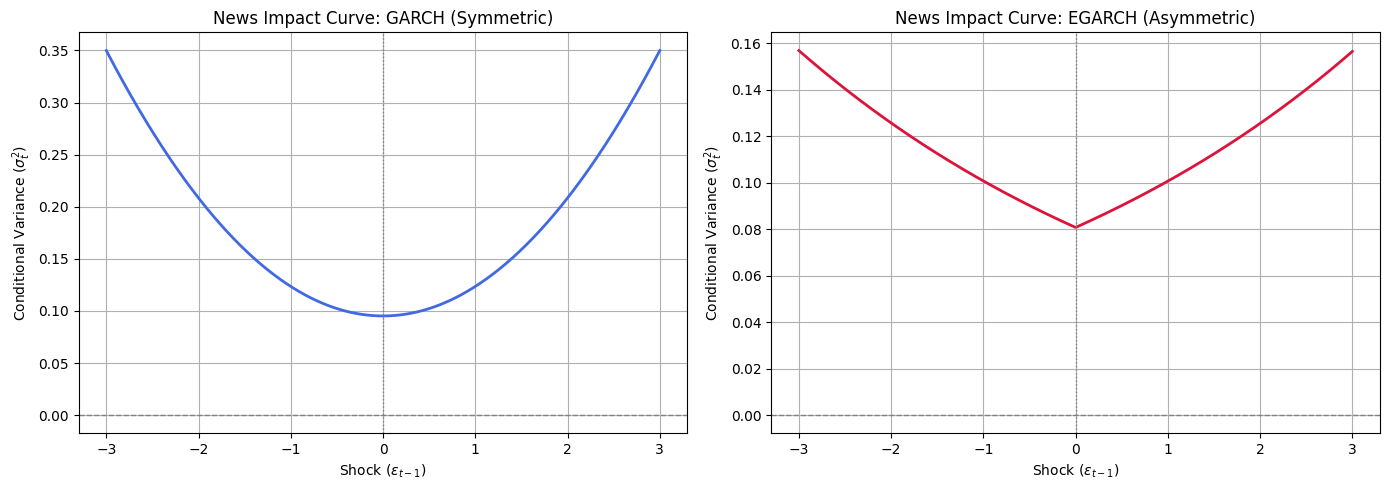

In [19]:
epsilon = np.linspace(-3, 3, 500)

# sigma_t^2 = omega + alpha * epsilon^2 + beta * sigma_longrun^2
garch_omega = garch_res.params['omega']
garch_alpha = garch_res.params['alpha[1]']
garch_beta = garch_res.params['beta[1]']
garch_var_longrun = garch_res.conditional_volatility.var() # Baseline variance proxy

garch_news_impact = garch_omega + (garch_alpha * (epsilon**2)) + (garch_beta * garch_var_longrun)

# ln(sigma_t^2) = omega + alpha * z + gamma * (|z| - sqrt(2/pi)) + beta * ln(sigma_longrun^2)
# where z = epsilon / sigma_longrun
egarch_omega = egarch_res.params["omega"]
egarch_alpha = egarch_res.params["alpha[1]"]  
egarch_gamma = egarch_res.params["gamma[1]"] # asymmetry effect
egarch_beta = egarch_res.params["beta[1]"]
egarch_var_longrun = egarch_res.conditional_volatility.var()

# EGARCH models use standardized shocks z
z = epsilon / np.sqrt(egarch_var_longrun)
egarch_log_var = (
    egarch_omega
    + egarch_alpha * (np.abs(z) - np.sqrt(2 / np.pi))
    + egarch_gamma * z
    + egarch_beta * np.log(egarch_var_longrun)
)
egarch_news_impact = np.exp(egarch_log_var)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(epsilon, garch_news_impact, color='royalblue', linewidth=2)
axs[0].set_title("News Impact Curve: GARCH (Symmetric)")
axs[0].set_xlabel("Shock ($\epsilon_{t-1}$)")
axs[0].set_ylabel("Conditional Variance ($\sigma_t^2$)")
axs[0].axhline(0, linewidth=1, linestyle="--", color="gray")
axs[0].axvline(0, linewidth=1, linestyle=":", color="gray")

axs[1].plot(epsilon, egarch_news_impact, color='crimson', linewidth=2)
axs[1].set_title("News Impact Curve: EGARCH (Asymmetric)")
axs[1].set_xlabel("Shock ($\epsilon_{t-1}$)")
axs[1].set_ylabel("Conditional Variance ($\sigma_t^2$)")
axs[1].axhline(0, linewidth=1, linestyle="--", color="gray")
axs[1].axvline(0, linewidth=1, linestyle=":", color="gray")

plt.tight_layout()
plt.show()

In [20]:
print(egarch_res.params["gamma[1]"])

-0.00011678743208213589


### Interpretation of News Impact Curves

The News Impact Curve (NIC) illustrates how shocks of different magnitudes affect the conditional variance predicted by the estimated volatility models.

* The GARCH(1,1) News Impact Curve is symmetric, indicating that positive and negative shocks of the same magnitude have an identical effect on future volatility. Volatility increases as the size of the shock increases, regardless of its sign.

* The EGARCH(1,1) News Impact Curve is also nearly symmetric. Although EGARCH allows for asymmetric volatility responses, the estimated asymmetry parameter is very close to zero, indicating that positive and negative shocks have almost the same impact on conditional variance in this portfolio.

**Overall, both models suggest that future volatility is driven primarily by the magnitude of shocks rather than their direction.** The absence of a pronounced leverage effect implies that the standard GARCH model is sufficient to capture the volatility dynamics of the portfolio.

## 8. In-Sample Value-at-Risk

For a one-day **95% VaR**, the VaR is calculated using a volatility-adjusted historical simulation approach:

$$VaR_{t,0.05} = 0 + \sigma_t \times q_{0.05}$$

where $\sigma_t$ is the conditional volatility generated by the GARCH model, and $q_{0.05}$ is the empirical 5% quantile of the historically standardized returns. 

The standardized returns are calculated by:

$$\text{standardized\_returns} = \frac{\text{sample\_returns} - \text{sample\_mean}}{\text{sample\_std}}$$

This structural normalization enables the risk threshold to scale dynamically based on the current period's conditional market volatility. 

**A VaR breach occurs when the realized return falls below the calculated VaR estimate**.

,breach_rate,breach_days
breach_VaR_GARCH,0.0424,62.0
breach_VaR_EGARCH,0.0431,63.0


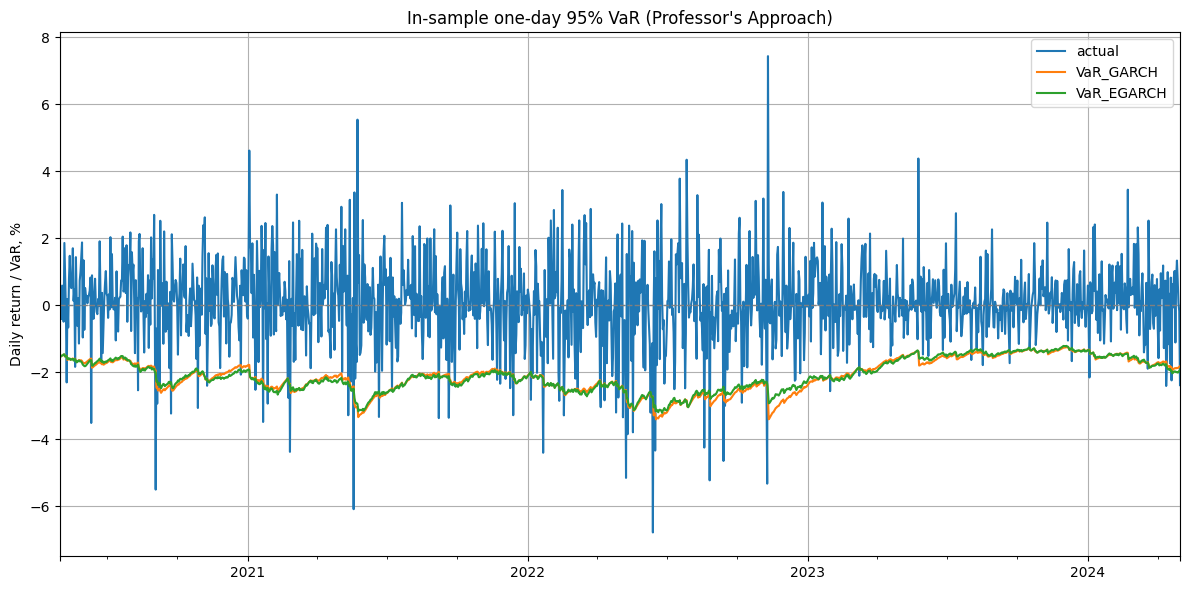

In [21]:
def generate_var_series(res, insample, alpha=0.05):
  
    insample_mean = insample.mean()
    insample_std = insample.std()
    standardized_returns = (insample - insample_mean) / insample_std
    
    # Get the empirical quantile based on the standardized returns
    q = np.percentile(standardized_returns, alpha * 100)
    
    sigma = res.conditional_volatility
    var_series = 0 + sigma * q
    
    return pd.Series(var_series, index=sigma.index)

alpha = 0.05

var_insample = pd.DataFrame({
    "actual": insample,
    "VaR_GARCH": generate_var_series(garch_res, insample, alpha),
    "VaR_EGARCH": generate_var_series(egarch_res, insample, alpha)
}).dropna()

for col in ["VaR_GARCH", "VaR_EGARCH"]:
    var_insample[f"breach_{col}"] = var_insample["actual"] < var_insample[col]

display(var_insample[[c for c in var_insample.columns if "breach" in c]]
        .agg(["mean", "sum"])
        .T
        .rename(columns={"mean": "breach_rate", "sum": "breach_days"})
        .round(4))

fig, ax = plt.subplots(figsize=(12, 6))
var_insample[["actual", "VaR_GARCH", "VaR_EGARCH"]].plot(ax=ax)
ax.axhline(0, linewidth=1, linestyle="--", color="gray")
ax.set_title("In-sample one-day 95% VaR (Professor's Approach)")
ax.set_ylabel("Daily return / VaR, %")
plt.tight_layout()
plt.show()

# 9. Out-of-Sample VaR by Walk-Forward Forecasting

The Out-of-Sample VaR is calculated by using an **expanding walk-forward** scheme:

1. Estimate a model using all observations available up to day t-1,
2. Forecast one-day-ahead conditional variance for day t,
3. Compute one-day VaR for day t,
4. Observe the actual return,
5. Add the realized return to the estimation sample and move to the next day.

This is repeated through the 365-day out-of-sample period.

In [22]:
def one_step_var_forecast(y_train, model_type, p, q, alpha=0.05):
    if model_type == "GARCH":
        am = arch_model(y_train, mean="Constant", vol="GARCH", p=p, q=q, dist="t", rescale=False)
    elif model_type == "EGARCH":
        am = arch_model(y_train, mean="Constant", vol="EGARCH", p=p, o=1, q=q, dist="t", rescale=False)
    else:
        raise ValueError("model_type must be 'GARCH' or 'EGARCH'")

    # Fit the model on the historical training data
    res = am.fit(disp="off", show_warning=False)
    
    # 1. Standardize the historical training returns 
    train_mean = y_train.mean()
    train_std = y_train.std()
    standardized_train_returns = (y_train - train_mean) / train_std
    
    # 2. Get the empirical quantile based on the standardized training data
    q_alpha = np.percentile(standardized_train_returns, alpha * 100)
    
    # 3. Extract the 1-step-ahead conditional volatility forecast
    fcast = res.forecast(horizon=1, reindex=False)
    variance = fcast.variance.iloc[-1, 0]
    sigma = np.sqrt(variance)
    
    # 4. Apply the formula: 0 + conditional_volatility * quantile
    var = 0 + sigma * q_alpha
    
    # Keep track of the GARCH model's implied mean for transparency/logging
    mu_model = fcast.mean.iloc[-1, 0]
    
    return var, mu_model, sigma, res.aic, res.bic

def rolling_var(y_full, insample_end, oos_start, oos_end, model_type, p, q, alpha=0.05):
    y_oos = y_full.loc[oos_start:oos_end].dropna()
    rows = []
    for date, actual in y_oos.items():
        y_train = y_full.loc[:date].iloc[:-1].dropna()
        try:
            var, mu, sigma, aic, bic = one_step_var_forecast(y_train, model_type, p, q, alpha)
            rows.append({
                "date": date,
                "actual": actual,
                "VaR": var,
                "mean_forecast": mu,
                "sigma_forecast": sigma,
                "aic": aic,
                "bic": bic,
                "breach": actual < var
            })
        except Exception as e:
            rows.append({
                "date": date,
                "actual": actual,
                "VaR": np.nan,
                "mean_forecast": np.nan,
                "sigma_forecast": np.nan,
                "aic": np.nan,
                "bic": np.nan,
                "breach": np.nan,
                "error": str(e)
            })
    return pd.DataFrame(rows).set_index("date")

print("Generate the out-of-sample rolling forecasts")
rolling_garch = rolling_var(portfolio_pct, insample_end, oos_start, oos_end, "GARCH", p_best, q_best, alpha)
rolling_egarch = rolling_var(portfolio_pct, insample_end, oos_start, oos_end, "EGARCH", p_best, q_best, alpha)

print("Result for GARCH forecasting...")
display(rolling_garch.head())
print("Result for EGARCH forecasting...")
display(rolling_egarch.head())

Generate the out-of-sample rolling forecasts
Result for GARCH forecasting...


,actual,VaR,mean_forecast,sigma_forecast,aic,bic,breach
date,,,,,,,
2024-05-01,-1.164448,-1.913658,0.108342,1.173967,4641.547413,4668.032868,False
2024-05-02,1.059609,-1.921064,0.107469,1.179066,4645.440207,4671.929049,False
2024-05-03,1.707869,-1.914589,0.108367,1.174637,4648.443467,4674.935693,False
2024-05-04,0.090237,-1.944137,0.109509,1.192474,4653.293252,4679.788859,False
2024-05-05,0.125808,-1.917349,0.109413,1.175726,4654.925867,4681.424854,False


Result for EGARCH forecasting...


,actual,VaR,mean_forecast,sigma_forecast,aic,bic,breach
date,,,,,,,
2024-05-01,-1.164448,-2.027524,0.100769,1.243820,4639.419316,4671.201862,False
2024-05-02,1.059609,-2.054407,0.099906,1.260906,4643.183618,4674.970228,False
2024-05-03,1.707869,-2.054918,0.100674,1.260731,4646.176214,4677.966885,False
2024-05-04,0.090237,-2.092695,0.101214,1.283594,4650.837626,4682.632354,False
2024-05-05,0.125808,-2.041508,0.101250,1.251861,4652.633907,4684.432691,False


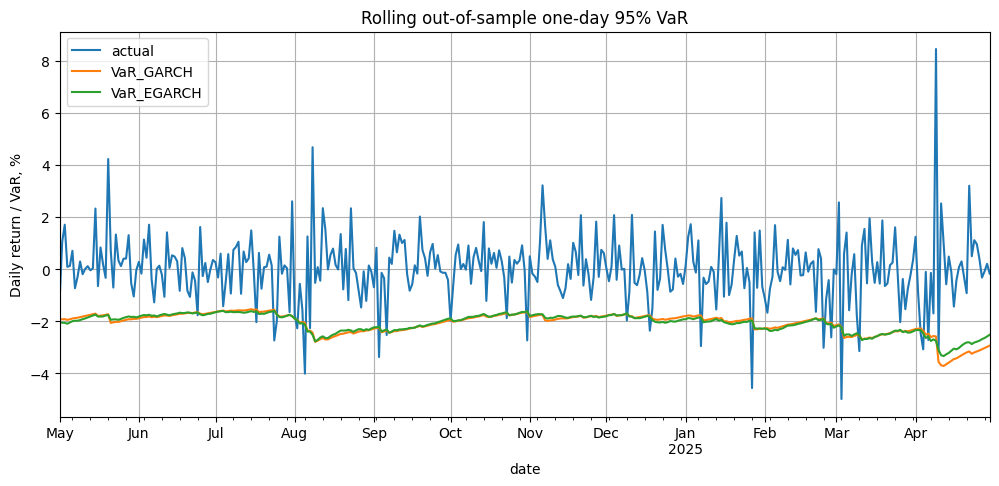

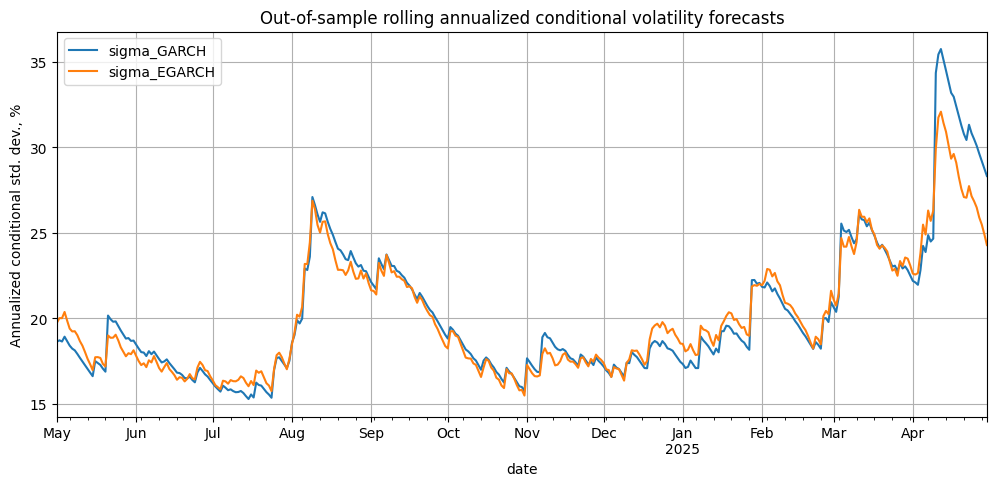

In [23]:
rolling_compare = pd.DataFrame({
    "actual": rolling_garch["actual"],
    "VaR_GARCH": rolling_garch["VaR"],
    "VaR_EGARCH": rolling_egarch["VaR"],
    "sigma_GARCH": rolling_garch["sigma_forecast"],
    "sigma_EGARCH": rolling_egarch["sigma_forecast"],
}).dropna()

rolling_compare["breach_GARCH"] = rolling_compare["actual"] < rolling_compare["VaR_GARCH"]
rolling_compare["breach_EGARCH"] = rolling_compare["actual"] < rolling_compare["VaR_EGARCH"]

fig, ax = plt.subplots()
rolling_compare[["actual", "VaR_GARCH", "VaR_EGARCH"]].plot(ax=ax)
ax.set_title("Rolling out-of-sample one-day 95% VaR")
ax.set_ylabel("Daily return / VaR, %")
plt.show()

fig, ax = plt.subplots()
(rolling_compare[["sigma_GARCH", "sigma_EGARCH"]] * np.sqrt(252)).plot(ax=ax)
ax.set_title("Out-of-sample rolling annualized conditional volatility forecasts")
ax.set_ylabel("Annualized conditional std. dev., %")
plt.show()

# 10. VaR backtesting and comparison

The central out-of-sample comparison is the share of days when the actual return was below the model's VaR. For a 95% VaR, the expected breach rate is approximately 5%.

This section reports:

- number of VaR breaches,
- breach rate,
- Kupiec unconditional coverage test,
- mean absolute VaR exceedance on breach days,
- comparison of the two models.

,n,breaches,breach_rate,LR_uc,p_value,mean_exceedance_given_breach,expected_breach_rate
model,,,,,,,
GARCH,365,22,0.0603,0.7633,0.3823,0.8105,0.05
EGARCH,365,23,0.0630,1.2065,0.2720,0.7533,0.05


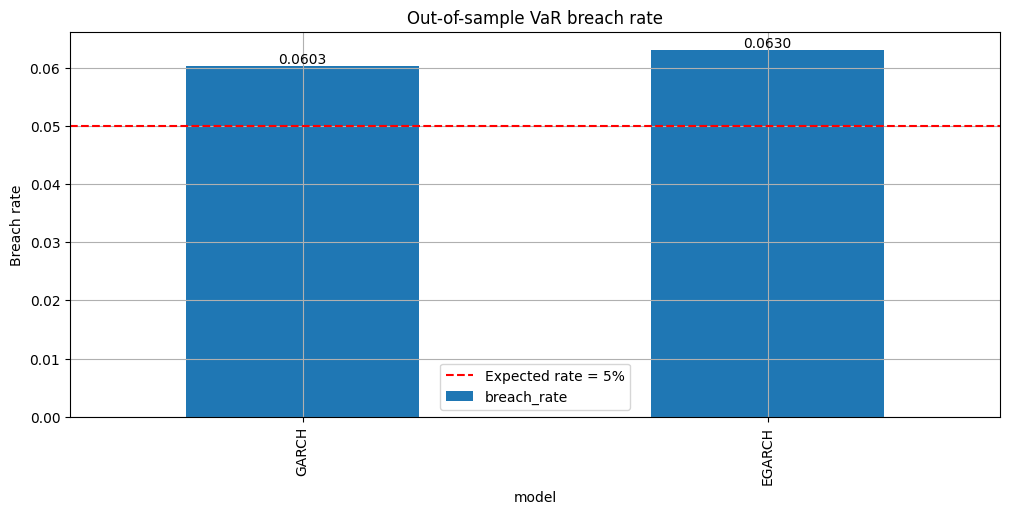

In [24]:
def kupiec_test(breaches, alpha=0.05):
    breaches = pd.Series(breaches).dropna().astype(bool)
    n = len(breaches)
    x = breaches.sum()
    if x == 0 or x == n:
        return {"n": n, "breaches": x, "breach_rate": x/n, "LR_uc": np.nan, "p_value": np.nan}
    phat = x / n
    lr = -2 * (
        (n - x) * np.log((1 - alpha) / (1 - phat)) +
        x * np.log(alpha / phat)
    )
    pval = 1 - chi2.cdf(lr, df=1)
    return {"n": n, "breaches": x, "breach_rate": phat, "LR_uc": lr, "p_value": pval}

def var_backtest_table(df, alpha=0.05):
    rows = []
    for model in ["GARCH", "EGARCH"]:
        var_col = f"VaR_{model}"
        breach_col = f"breach_{model}"
        kt = kupiec_test(df[breach_col], alpha)
        exceedance = (df[var_col] - df["actual"])[df[breach_col]]
        kt["model"] = model
        kt["mean_exceedance_given_breach"] = exceedance.mean() if len(exceedance) else 0.0
        kt["expected_breach_rate"] = alpha
        rows.append(kt)
    return pd.DataFrame(rows).set_index("model")

backtest = var_backtest_table(rolling_compare, alpha)
display(backtest.round(4))

fig, ax = plt.subplots()
backtest["breach_rate"].plot(kind="bar", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.4f")
ax.axhline(alpha, linestyle="--", color="red", label=f"Expected rate = {alpha:.0%}")
ax.set_title("Out-of-sample VaR breach rate")
ax.set_ylabel("Breach rate")
ax.legend()
plt.show()

### Interpretation of out-of-sample VaR backtesting results

#### 1. Breach Frequency Analysis

For a sample of 365 observations, the expected number of VaR breaches equals:

$$
365 \times 0.05 = 18.25
$$

Both models generated a slightly higher number of breaches than expected:

- **GARCH(1,1):** 22 breaches (6.03%)
- **EGARCH(1,1):** 23 breaches (6.30%)

Consequently, **both models slightly underestimated portfolio risk during the out-of-sample period**. However, the differences between the observed and theoretical breach rates are relatively small, suggesting that both models provide reasonably accurate VaR forecasts.

#### 2. Kupiec Unconditional Coverage Test

The adequacy of the VaR forecasts was formally assessed using the Kupiec Unconditional Coverage test. The null hypothesis states that the observed breach frequency is equal to the theoretical breach probability.

| Model | LR Statistic | p-value |
|---------|---------:|---------:|
| GARCH(1,1) | 0.7633 | 0.3823 |
| EGARCH(1,1) | 1.2065 | 0.2720 |

For both models, the p-values are well above the conventional 5% significance level. Therefore, the null hypothesis cannot be rejected, indicating that **the observed number of breaches is statistically consistent with the expected 5% breach rate**.

From a regulatory and risk-management perspective, both models pass the unconditional coverage test and can be considered acceptable VaR forecasting frameworks.

#### 3. Comparison of Breach Severity

The average exceedance beyond the VaR threshold was slightly smaller for the EGARCH model:

- **GARCH(1,1):** 0.8105
- **EGARCH(1,1):** 0.7533

This suggests that, conditional on a breach occurring, **the losses beyond the VaR threshold were marginally less severe under the EGARCH specification**. However, the difference is relatively small and should not be interpreted as strong evidence of superior forecasting performance.

#### 4. Overall Assessment

The backtesting results indicate that both GARCH(1,1) and EGARCH(1,1) provide satisfactory Value-at-Risk forecasts for the considered portfolio. Both models successfully pass the Kupiec test and produce breach rates close to the theoretical 5% level.

Although EGARCH exhibits slightly lower average exceedance severity, it also generates a marginally higher number of breaches and a lower Kupiec p-value. Therefore, the empirical evidence does not clearly support the conclusion that one model consistently outperforms the other.

**Overall, the forecasting accuracy of the two specifications appears very similar. Given its slightly lower breach frequency and stronger unconditional coverage results, the standard GARCH(1,1) model may be preferred due to its simpler structure and comparable predictive performance**.